In [7]:
from src.core.analysis.hard_cases_analysis import analyse_hard_cases
from sklearn.metrics import mean_absolute_error
from src.utils.config import MODEL_PATH,X_TEST_PATH,Y_TEST_PATH,X_TRAIN_PATH,Y_TRAIN_PATH,RAW_DATA_PATH
import joblib
import pandas as pd
import numpy as np

In [2]:
model = joblib.load(MODEL_PATH)


X_test = joblib.load(X_TEST_PATH)
y_test = joblib.load(Y_TEST_PATH)
X_train = joblib.load(X_TRAIN_PATH)
y_train = joblib.load(Y_TRAIN_PATH)
pred=model.predict(X_test)

In [3]:
X_test['cyp2c9'].value_counts()

cyp2c9
2.0    821
1.5    140
1.0    126
0.5     15
0.0      4
Name: count, dtype: int64

In [4]:
X_test['vkorc1'].value_counts()

vkorc1
UNKNOWN    310
AA         294
AG         263
GG         239
Name: count, dtype: int64

In [5]:
len(X_test)

1106

In [6]:
y_pred_base = model.predict(X_test)
test_df = X_test.copy()
test_df['true_dose'] = y_test
test_df['pred_dose'] = y_pred_base
test_df['abs_error'] = np.abs(test_df['true_dose'] - test_df['pred_dose'])
test_df['within_20'] = (test_df['abs_error'] / test_df['true_dose']) <= 0.20

test_df['age_80_plus'] = test_df['age_decade'] >= 8 # 8 = "80-89" or "90+"

def subgroup_stats(df, mask, name):
    sub = df[mask]
    n = len(sub)
    if n == 0: return {'N': 0, 'MAE': np.nan, 'Within20%': np.nan}
    return {
        'N': n,
        'MAE': sub['abs_error'].mean().round(2),
        'Within20%': (sub['within_20'].mean() * 100).round(1)
    }

# Key subgroups clinicians care about
results = {}
results['Overall'] = subgroup_stats(test_df, np.ones(len(test_df), dtype=bool), 'Overall')
results['Age 80+'] = subgroup_stats(test_df, test_df['age_80_plus'], 'Age 80+')
results['CYP2C9 *3/*3'] = subgroup_stats(test_df, test_df['cyp2c9'] == 0.0, '*3/*3')
results['CYP2C9 *1/*1'] = subgroup_stats(test_df, test_df['cyp2c9'] == 2.0, '*1/*1')
results['CYP2C9 *1/*2'] = subgroup_stats(test_df, test_df['cyp2c9'] == 1.5, '*1/*2')
results['CYP2C9 *2/*2/*2/*3'] = subgroup_stats(test_df, test_df['cyp2c9'] == 1.0, '*2/*2')#both *2/*2 and *2/*3
results['BMI 30-40'] = subgroup_stats(test_df, (test_df['bmi'] >= 30) & (test_df['bmi'] < 40), 'BMI 30-40')
results['Amiodarone'] = subgroup_stats(test_df, test_df['amiodarone'] == 1, 'Amiodarone')
results['Vkorc1_AA'] = subgroup_stats(test_df, test_df['vkorc1'] == 'AA', 'Vkorc1_AA')
results['Vkorc1_UNKNOWN'] = subgroup_stats(test_df, test_df['vkorc1'] == 'UNKNOWN', 'Vkorc1_UNKNOWN')
results['Vkorc1_GG'] = subgroup_stats(test_df, test_df['vkorc1'] == 'GG', 'Vkorc1_GG')


pd.DataFrame(results).T


,N,MAE,Within20%
Overall,1106.0,9.65,41.9
Age 80+,133.0,7.01,47.4
CYP2C9 *3/*3,4.0,10.44,25.0
CYP2C9 *1/*1,821.0,9.97,43.7
CYP2C9 *1/*2,140.0,9.53,39.3
CYP2C9 *2/*2/*2/*3,126.0,7.76,37.3
BMI 30-40,186.0,11.93,44.1
Amiodarone,86.0,8.86,44.2
Vkorc1_AA,294.0,6.06,42.9
Vkorc1_UNKNOWN,310.0,11.35,34.2


c:\Users\USER\Desktop\Warfarin_IWPC_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


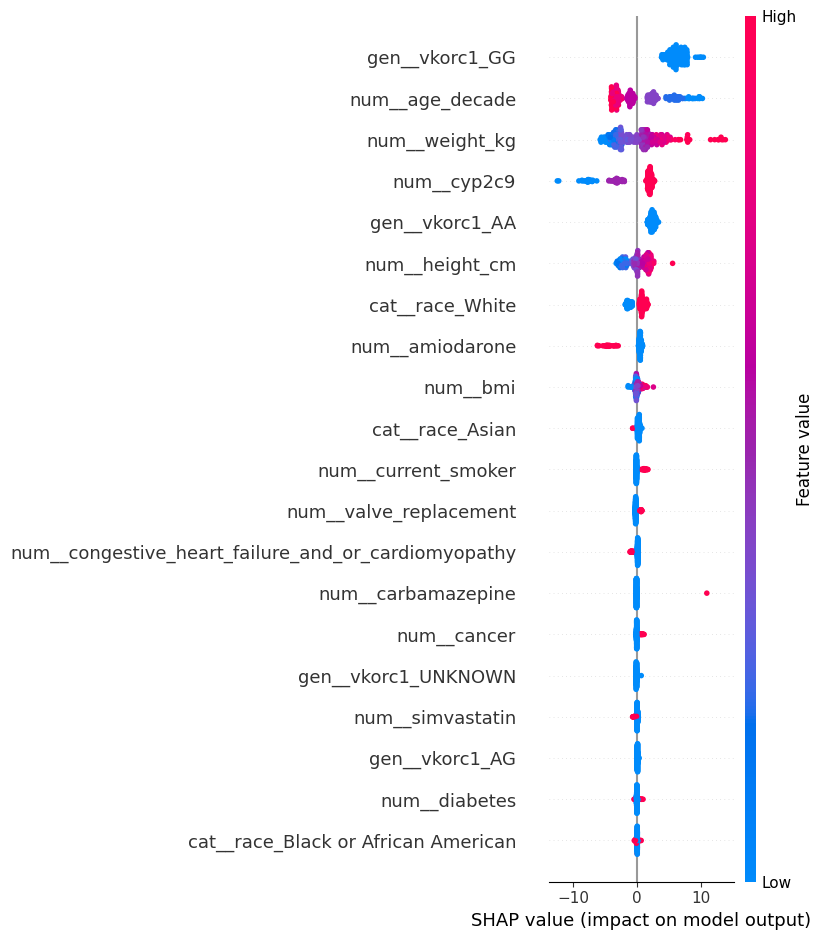

In [7]:
import shap
model = joblib.load(MODEL_PATH)
preprocessor = model.named_steps["preprocessor"]
xgb_model = model.named_steps["model"]


X_test=X_test[X_test['vkorc1']=='GG']

X_test_transformed = preprocessor.transform(X_test)
X_test_transformed=X_test_transformed
    
feature_names = preprocessor.get_feature_names_out()
 

explainer = shap.TreeExplainer(xgb_model,feature_perturbation="tree_path_dependent")

shap_values = explainer.shap_values(X_test_transformed)
X_plot=pd.DataFrame(X_test_transformed.toarray() if hasattr(X_test_transformed,"toarray") else X_test_transformed,columns=feature_names)
 
shap.summary_plot(
        shap_values,
        X_plot,
        max_display=20,
        show=False)

In [ ]:
hard_cases, easy_cases, comparison, genotype_comparison = analyse_hard_cases(
    X_test, y_test, pred
)
hard_cases[['age_decade','weight_kg','height_cm','bmi','cyp2c9']].describe()

Hard cases (top 20%): 222
Easy cases (bottom 80%): 884

TOP FEATURES DRIVING ERROR (Hard vs Easy):
Feature
weight_kg                               9.425083
height_cm                               3.027037
bmi                                     2.795205
age_decade                             -0.587700
acetaminophen_or_paracetamol_tylenol    0.101498
current_smoker                          0.080252
azole                                   0.062880
simvastatin                             0.056897
valve_replacement                      -0.054833
hypertension                            0.044128
diabetes                                0.042224
cyp2c9                                  0.039246
cancer                                  0.036984
phenytoin                               0.027007
anti_fungal_azoles                      0.020083
Name: Diff, dtype: float64

GENOTYPE DISTRIBUTION: vkorc1
             Hard      Easy      Diff
vkorc1                               
UNKNOWN  0.423423  0.244

,age_decade,weight_kg,height_cm,bmi,cyp2c9
count,222.000000,212.000000,169.000000,168.000000,222.000000
mean,5.391892,85.432547,170.836036,29.591625,1.826577
std,1.529359,24.845401,10.216460,7.942082,0.350005
min,2.000000,43.000000,142.010000,17.352697,0.000000
25%,4.000000,67.700000,162.560000,24.080647,2.000000
50%,5.000000,81.900000,171.200000,28.191017,2.000000
75%,6.000000,98.000000,179.070000,32.434096,2.000000
max,9.000000,177.300000,193.040000,60.941043,2.000000


: 

In [23]:

errors_base = np.abs(y_test - pred)
hard_error_mask = errors_base >= np.quantile(errors_base, 0.8)
baseline_hard_mae = errors_base[hard_error_mask].mean()
baseline_overall_mae = mean_absolute_error(y_test, pred)

print(f"BASELINE: Overall MAE={baseline_overall_mae:.2f}, Hard MAE={baseline_hard_mae:.2f}, N_hard={hard_error_mask.sum()}")
# ============================================

BASELINE: Overall MAE=9.55, Hard MAE=24.54, N_hard=222


In [24]:
X_test[hard_error_mask]['cyp2c9'].value_counts()


cyp2c9
2.0    172
1.5     30
1.0     18
0.5      2
Name: count, dtype: int64

In [25]:
X_test[hard_error_mask]['vkorc1'].value_counts()

vkorc1
UNKNOWN    88
GG         75
AG         44
AA         15
Name: count, dtype: int64

In [26]:
X_test[hard_error_mask][X_test[hard_error_mask]['cyp2c9']==2.0]['vkorc1'].value_counts()

vkorc1
UNKNOWN    72
GG         56
AG         31
AA         13
Name: count, dtype: int64

In [27]:
bins = [0, 21, 49, 1000]
labels = ['Low <21', 'Medium 21-49', 'High >49']
test_df['true_bin'] = pd.cut(test_df['true_dose'], bins=bins, labels=labels)
test_df['pred_bin'] = pd.cut(test_df['pred_dose'], bins=bins, labels=labels)
print(pd.crosstab(test_df['true_bin'], test_df['pred_bin'], normalize='index').round(2))

pred_bin      Low <21  Medium 21-49  High >49
true_bin                                     
Low <21          0.42          0.57      0.01
Medium 21-49     0.07          0.89      0.04
High >49         0.01          0.69      0.29


In [28]:
print(pd.crosstab(test_df['true_bin'],test_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
true_bin                                            
Low <21       0.526455  0.222222  0.058201  0.193122
Medium 21-49  0.157265  0.275214  0.256410  0.311111
High >49      0.020979  0.125874  0.468531  0.384615


In [29]:
print(pd.crosstab(test_df['pred_bin'],test_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
pred_bin                                            
Low <21       0.823529  0.093137  0.009804  0.073529
Medium 21-49  0.150898  0.285030  0.223952  0.340120
High >49      0.000000  0.089552  0.746269  0.164179


In [30]:
print(pd.crosstab(test_df['true_bin'],test_df['cyp2c9'],normalize='index'))

cyp2c9             0.0       0.5       1.0       1.5       2.0
true_bin                                                      
Low <21       0.007937  0.029101  0.177249  0.116402  0.669312
Medium 21-49  0.001709  0.006838  0.088889  0.143590  0.758974
High >49      0.000000  0.000000  0.048951  0.083916  0.867133


In [31]:
print(pd.crosstab(test_df['pred_bin'],test_df['cyp2c9'],normalize='index'))

cyp2c9             0.0       0.5       1.0       1.5       2.0
pred_bin                                                      
Low <21       0.009804  0.044118  0.245098  0.019608  0.681373
Medium 21-49  0.002395  0.007186  0.091018  0.158084  0.741317
High >49      0.000000  0.000000  0.000000  0.059701  0.940299


In [32]:
bins = [0, 21, 49, 1000]
labels = ['Low <21', 'Medium 21-49', 'High >49']
test_df['hard_error_mask']=hard_error_mask
hard_df=test_df[test_df['hard_error_mask']].copy()
hard_df['true_bin'] = pd.cut(hard_df['true_dose'], bins=bins, labels=labels)
hard_df['pred_bin'] = pd.cut(hard_df['pred_dose'], bins=bins, labels=labels)
print(pd.crosstab(hard_df['true_bin'], hard_df['pred_bin'], normalize='index').round(2))

pred_bin      Low <21  Medium 21-49  High >49
true_bin                                     
Low <21          0.03          0.94      0.03
Medium 21-49     0.11          0.73      0.16
High >49         0.02          0.75      0.23


In [33]:
print(pd.crosstab(hard_df['true_bin'],hard_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
true_bin                                            
Low <21       0.130435  0.246377  0.217391  0.405797
Medium 21-49  0.053571  0.267857  0.303571  0.375000
High >49      0.030928  0.123711  0.443299  0.402062


In [34]:
print(pd.crosstab(hard_df['pred_bin'],hard_df['vkorc1'],normalize='index'))

vkorc1              AA        AG        GG   UNKNOWN
pred_bin                                            
Low <21       0.400000  0.000000  0.100000  0.500000
Medium 21-49  0.061453  0.234637  0.251397  0.452514
High >49      0.000000  0.060606  0.878788  0.060606


In [35]:
print(pd.crosstab(hard_df['true_bin'],hard_df['cyp2c9'],normalize='index'))

cyp2c9             0.5       1.0       1.5       2.0
true_bin                                            
Low <21       0.000000  0.072464  0.202899  0.724638
Medium 21-49  0.035714  0.107143  0.125000  0.732143
High >49      0.000000  0.072165  0.092784  0.835052


In [36]:
print(pd.crosstab(hard_df['pred_bin'],hard_df['cyp2c9'],normalize='index'))

cyp2c9        0.5       1.0       1.5       2.0
pred_bin                                       
Low <21       0.2  0.400000  0.000000  0.400000
Medium 21-49  0.0  0.078212  0.156425  0.765363
High >49      0.0  0.000000  0.060606  0.939394


In [37]:
df= pd.read_csv(RAW_DATA_PATH)
df.groupby('Race')['Cyp2C9 genotypes'].value_counts()

Race                       Cyp2C9 genotypes
Asian                      *1/*1               1457
                           *1/*3                103
                           *3/*3                  2
                           *1/*13                 1
                           *1/*14                 1
                           *1/*2                  1
Black or African American  *1/*1                391
                           *1/*2                 23
                           *1/*3                 10
                           *1/*5                  6
                           *1/*11                 5
                           *1/*6                  3
Unknown                    *1/*1                338
                           *1/*2                 92
                           *1/*3                 36
                           *2/*2                  6
                           *2/*3                  4
                           *3/*3                  3
White               

In [39]:
df.groupby('Race')['VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T'].value_counts()

Race                       VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T
Asian                      A/A                                                                  1109
                           A/G                                                                   210
                           G/G                                                                    15
Black or African American  G/G                                                                   250
                           A/G                                                                    51
                           A/A                                                                     5
Unknown                    A/G                                                                   110
                           G/G                                                                   108
                           A/A                                                                    2

In [40]:
pd.crosstab(df['Race'], df['VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T'], normalize='index').round(3)
pd.crosstab(df['Race'], df['Cyp2C9 genotypes'], normalize='index').round(3)

Cyp2C9 genotypes,*1/*1,*1/*11,*1/*13,*1/*14,*1/*2,*1/*3,*1/*5,*1/*6,*2/*2,*2/*3,*3/*3
Race,,,,,,,,,,,
Asian,0.931,0.000,0.001,0.001,0.001,0.066,0.000,0.000,0.000,0.000,0.001
Black or African American,0.893,0.011,0.000,0.000,0.053,0.023,0.014,0.007,0.000,0.000,0.000
Unknown,0.706,0.000,0.000,0.000,0.192,0.075,0.000,0.000,0.013,0.008,0.006
White,0.638,0.000,0.000,0.000,0.203,0.114,0.000,0.000,0.017,0.022,0.006


In [41]:
pd.crosstab(df['Race'], df['VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T'], normalize='index').round(3)

VKORC1 genotype: -1639 G>A (3673); chr16:31015190; rs9923231; C/T,A/A,A/G,G/G
Race,,,
Asian,0.831,0.157,0.011
Black or African American,0.016,0.167,0.817
Unknown,0.117,0.445,0.437
White,0.145,0.489,0.366


In [42]:
X_test['race'].value_counts()

race
White                        592
Asian                        324
Black or African American    107
Unknown                       83
Name: count, dtype: int64